# CNN — Speech Emotion Recognition

Unlike the MLP which averaged features over time into a flat vector, the CNN operates on the full MFCC matrix and learns local temporal patterns via 1D convolutions. Each filter slides over the time axis and learns to detect a specific short-term pattern in the signal.

The tradeoff: CNNs capture local patterns well but still lack a global view of the full utterance. That is left for the LSTM stage.

## Imports

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import glob
import os
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from data_loader import prepare_data

## Config

In [11]:
DATASET_PATH = "Audio_Speech_Actors_01-24"
MAX_LEN      = 300    # all clips padded or truncated to this length
BATCH_SIZE   = 32
N_EPOCHS     = 100
LR           = 1e-3
DROPOUT      = 0.5
WEIGHT_DECAY = 1e-4
PATIENCE     = 50     # early stopping patience

EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

## Window Length Distribution

Clips have variable length depending on the utterance. Since a DataLoader requires fixed-size tensors, all clips need to be padded or truncated to a common length.

Plotting the distribution first to pick MAX_LEN informed by the data rather than arbitrarily. Target is to cover most clips without adding excessive padding to short ones.

Min: 196, Max: 352, Mean: 247.2, Std: 22.4


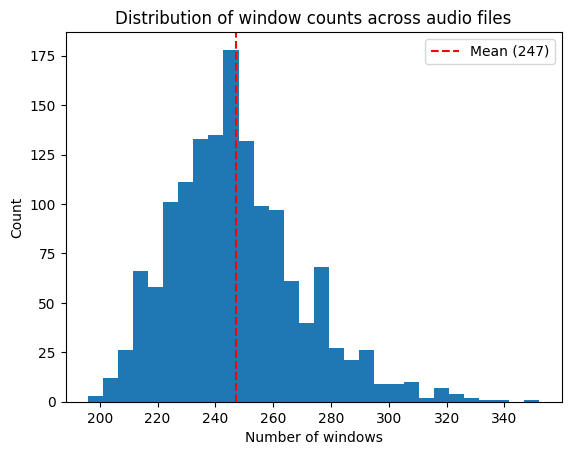

In [12]:
feature_files = glob.glob(os.path.join(DATASET_PATH, "Actor_*", "*.npz"))

window_counts = []
for filepath in feature_files:
    data = np.load(filepath)
    window_counts.append(data['mfcc'].shape[1])  # mfcc shape is (40, T)

window_counts = np.array(window_counts)
print(f"Min: {window_counts.min()}, Max: {window_counts.max()}, Mean: {window_counts.mean():.1f}, Std: {window_counts.std():.1f}")

plt.figure()
plt.hist(window_counts, bins=30)
plt.xlabel('Number of windows')
plt.ylabel('Count')
plt.title('Distribution of window counts across audio files')
plt.axvline(window_counts.mean(), color='r', linestyle='--', label=f'Mean ({window_counts.mean():.0f})')
plt.legend()
plt.show()

## Data Loading

`flatten=False` keeps the full `(n_features, T)` matrix per clip. The MLP used `flatten=True` which averaged over T.

Only MFCC and RMS are used as input channels. Deltas are dropped because the conv filters learn temporal derivatives implicitly from the raw MFCCs. RMS is kept because the energy contour over time carries prosodic information that the MFCC shape alone does not capture.

Input shape per clip: `(41, 300)` — 40 MFCC channels + 1 RMS channel, 300 time frames.

In [13]:
[x_train_torch,
 y_train_torch,
 x_val_torch,
 y_val_torch,
 x_test_torch,
 y_test_torch] = prepare_data(feature_files=feature_files,
                              flatten=False,
                              features=['mfcc', 'rms'],
                              max_len=MAX_LEN)

print(f"Train: {x_train_torch.shape} | Val: {x_val_torch.shape} | Test: {x_test_torch.shape}")

Loading data: 100%|██████████| 1440/1440 [00:00<00:00, 2021.11it/s]


Train: torch.Size([960, 41, 300]) | Val: torch.Size([240, 41, 300]) | Test: torch.Size([240, 41, 300])


## Model

Three conv blocks followed by two linear layers.

Each conv block: `Conv1d -> BatchNorm -> ReLU -> MaxPool -> Dropout`

**Conv1d** slides a filter of `kernel_size` frames over the time axis. Each filter output length is `T - (kernel_size - 1)`. With `kernel_size=5` each filter sees approximately 115ms of signal (at standard hop length).

**BatchNorm** normalizes activations across the batch after each conv layer. Keeps activations in a stable range and helps gradient flow through deeper networks.

**MaxPool1d(2,2)** halves the time dimension by keeping the max value in each non-overlapping window of 2 frames.

**Channels increase with depth** (32 -> 64 -> 128) because later layers learn combinations of earlier patterns, which occupy a larger representational space.

**Global Average Pooling** replaces flattening. After the conv blocks the tensor is `(batch, 128, T)`. Taking the mean over the time axis gives `(batch, 128)` regardless of T, removing the dependency on a fixed sequence length and keeping the linear head small.

**Dropout at 0.5** is the main regularization tool. With only ~960 training samples, the model overfits easily. Dropout also added after each conv block for the same reason.

In [14]:
class CNN(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=41, out_channels=32, kernel_size=5)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5)
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5)
        self.pool    = nn.MaxPool1d(2, 2)
        self.bn1     = nn.BatchNorm1d(32)
        self.bn2     = nn.BatchNorm1d(64)
        self.bn3     = nn.BatchNorm1d(128)
        self.fc1     = nn.Linear(128, 64)
        self.fc2     = nn.Linear(64, 8)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = self.dropout(self.pool(F.relu(self.bn1(self.conv1(x)))))
        x = self.dropout(self.pool(F.relu(self.bn2(self.conv2(x)))))
        x = self.dropout(self.pool(F.relu(self.bn3(self.conv3(x)))))
        x = x.mean(dim=-1)       # global average pooling: (batch, 128, T) -> (batch, 128)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)          # raw logits, no activation
        return x

## Training Setup

`weight_decay` in Adam adds L2 regularization — it penalizes large weights, which is another tool against overfitting on top of dropout.

In [15]:
model     = CNN(dropout_rate=DROPOUT)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

train_loader = DataLoader(TensorDataset(x_train_torch, y_train_torch), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(x_val_torch,   y_val_torch),   batch_size=BATCH_SIZE, shuffle=False)

## Training Loop

Val loss is computed every epoch. The best weights by val loss are saved to disk. Early stopping halts training if val loss has not improved for `PATIENCE` epochs, avoiding wasted compute when the model has already peaked.

Note: `model.train()` and `model.eval()` are called at each transition because BatchNorm and Dropout both behave differently between the two modes.

In [16]:
run_loss_vec    = []
val_loss_vec    = []
best_val_loss   = float('inf')
best_epoch      = 0
epochs_no_improve = 0

for epoch in range(N_EPOCHS):

    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        output = model(inputs)
        loss   = criterion(output, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    run_loss_vec.append(running_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            val_loss += criterion(model(inputs), labels).item()
    val_loss_vec.append(val_loss)

    print(f"Epoch {epoch+1}/{N_EPOCHS}  train: {running_loss:.4f}  val: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch    = epoch + 1
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'cnn_best.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"Best epoch: {best_epoch}")

Epoch 1/100  train: 60.6581  val: 15.9773
Epoch 2/100  train: 56.9763  val: 15.1537
Epoch 3/100  train: 53.6081  val: 14.7749
Epoch 4/100  train: 49.8534  val: 15.2243
Epoch 5/100  train: 47.2007  val: 15.0648
Epoch 6/100  train: 45.1533  val: 15.4997
Epoch 7/100  train: 43.9194  val: 15.1263
Epoch 8/100  train: 41.7329  val: 15.7092
Epoch 9/100  train: 41.2697  val: 16.9497
Epoch 10/100  train: 39.9818  val: 16.0596
Epoch 11/100  train: 39.5770  val: 17.7926
Epoch 12/100  train: 38.5479  val: 15.8995
Epoch 13/100  train: 36.2900  val: 18.1127
Epoch 14/100  train: 35.2640  val: 18.1179
Epoch 15/100  train: 36.1043  val: 18.2995
Epoch 16/100  train: 35.2522  val: 18.1544
Epoch 17/100  train: 33.7758  val: 17.5503
Epoch 18/100  train: 33.8374  val: 18.5182
Epoch 19/100  train: 32.0628  val: 18.7142
Epoch 20/100  train: 32.4057  val: 18.7789
Epoch 21/100  train: 31.8608  val: 18.2503
Epoch 22/100  train: 30.2610  val: 17.8820
Epoch 23/100  train: 30.4528  val: 18.8671
Epoch 24/100  train:

## Loss Curves

The gap between train and val loss shows how much the model is overfitting. A large and growing gap means the model is memorizing the training set rather than learning generalizable patterns.

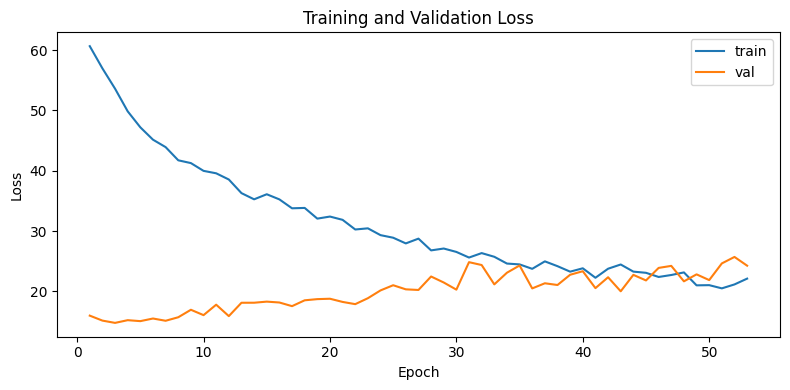

In [17]:
epochs_ran = len(run_loss_vec)
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs_ran + 1), run_loss_vec, label='train')
plt.plot(range(1, epochs_ran + 1), val_loss_vec, label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

## Evaluation

Load the best checkpoint before evaluating. The classification report shows per-class precision, recall and F1 — more informative than overall accuracy on an imbalanced dataset.

In [18]:
model.load_state_dict(torch.load('cnn_best.pth'))
model.eval()

correct    = 0
total      = 0
all_preds  = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

print(classification_report(all_labels, all_preds, target_names=list(EMOTION_MAP.values())))
print(f'Val accuracy: {100 * correct / total:.2f}%')
print(f'Best epoch: {best_epoch}')
print(f"Val label distribution:   {np.bincount(y_val_torch.numpy())}")
print(f"Train label distribution: {np.bincount(y_train_torch.numpy())}")

              precision    recall  f1-score   support

     neutral       0.00      0.00      0.00        16
        calm       0.35      0.59      0.44        32
       happy       0.40      0.06      0.11        32
         sad       0.06      0.09      0.07        32
       angry       0.59      0.62      0.61        32
     fearful       0.23      0.38      0.29        32
     disgust       0.00      0.00      0.00        32
   surprised       0.22      0.31      0.26        32

    accuracy                           0.28       240
   macro avg       0.23      0.26      0.22       240
weighted avg       0.25      0.28      0.24       240

Val accuracy: 27.50%
Best epoch: 3
Val label distribution:   [16 32 32 32 32 32 32 32]
Train label distribution: [ 64 128 128 128 128 128 128 128]


c:\Users\yotam\Documents\University\self learning\Emotion recognition from speech\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\yotam\Documents\University\self learning\Emotion recognition from speech\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\yotam\Documents\University\self learning\Emotion recognition from speech\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels wi